# 19 · Decoy-protein rescore: does the affinity head need the true protein?

Earlier notebooks found that ligand properties alone explain a good part of Boltz-2's score (descriptors reach AUROC 0.845 against 0.915 for the score). The mechanism claim, that the head reads protein-ligand interactions, was held back until this test: **score the same ligands against proteins that are not the target and see whether activity is still recovered.**

**Design.** 1,600 compounds (all 396 held-out actives and 1,204 random inactives) were co-folded and scored with the standard Boltz-2 protocol (co-fold plus affinity, five affinity samples), against three proteins:
- **real:** the true 588689 protein with its MSA. This is the control and checks that the protocol reproduces the dataset's scores.
- **shuffled:** the same amino-acid sequence randomly permuted, with no MSA. Same composition, no fold information.
- **other:** an unrelated real protein (target 493091, with its own MSA).

**How to read it.** If the decoy arms recover activity about as well as the real one, the head is mostly reading the ligand. If they fall towards chance, the protein matters. The active share here is 25% (not the library's 0.8%), which does not affect AUROC but does affect AP, so AP is compared with the 25% line.

In [1]:

import numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
from scipy import stats
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors
RDLogger.DisableLog("rdApp.*")
BLK="#000000"; GRN="#1baf7a"; CL="#d62728"; CO="#2a78d6"; NEU="#666666"; ORG="#e08a1e"; PUR="#9467bd"
mpl.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","savefig.facecolor":"white",
  "text.color":BLK,"axes.labelcolor":BLK,"axes.titlecolor":BLK,"xtick.color":BLK,"ytick.color":BLK,
  "axes.edgecolor":BLK,"font.size":10,"font.weight":"normal","axes.titleweight":"normal","axes.labelweight":"normal",
  "axes.grid":True,"grid.color":"#e6e6e6","axes.axisbelow":True,"axes.spines.top":False,"axes.spines.right":False})
ROOT=Path("/global/scratch/users/sergiomar10/boltzaff"); D=ROOT/"results/runs/588689/decoy"; A=ROOT/"results/analysis/588689/cliffs"
sub=pd.read_csv(D/"subset.csv").set_index("id"); sc=pd.read_csv(D/"scores.csv")
ARMS=[("real","real 588689 (control)",GRN),("shuffled","shuffled sequence, no MSA",CL),("other","unrelated protein (493091)",CO)]
W=sc.pivot(index="id",columns="arm",values="prob"); V=sc.pivot(index="id",columns="arm",values="value")
have=[a for a,_,_ in ARMS if a in W.columns]; comp=W[have].dropna().index
print("scored compounds per arm:",{a:int(W[a].notna().sum()) for a in have}," | in all arms:",len(comp),"of",len(sub))
sub["label"]=sub.target_active_v2.astype(int); y=sub.label.reindex(comp).values
# reference scores for the same compounds: the dataset's own Boltz-2 score, our No-FT pipeline score and the 5-seed head-FT score
S=pd.read_csv(A/"scores_seeds_eval.csv").set_index("id"); S["ft"]=S[[f"ft_p{s}" for s in range(5)]].mean(axis=1)
raw=pd.read_csv(ROOT/"data/mf-pcba_test/588689.csv"); raw["id"]="588689_"+raw.CID.astype(str); raw=raw.set_index("id")
REF={"dataset Boltz-2 score":raw.score_boltz2.reindex(comp),"No-FT (our pipeline)":S.noft_p.reindex(comp),"head-FT N=300 (5 seeds)":S.ft.reindex(comp)}
# ligand-only features
def props(smi):
    m=Chem.MolFromSmiles(smi); return (Descriptors.MolWt(m),Crippen.MolLogP(m),m.GetNumHeavyAtoms(),rdMolDescriptors.CalcTPSA(m),rdMolDescriptors.CalcNumHBD(m),rdMolDescriptors.CalcNumHBA(m),rdMolDescriptors.CalcNumRotatableBonds(m),rdMolDescriptors.CalcNumAromaticRings(m),rdMolDescriptors.CalcFractionCSP3(m)) if m else (np.nan,)*9
PN=["MW","logP","heavy atoms","TPSA","H-bond donors","H-bond acceptors","rotatable bonds","aromatic rings","fraction sp3"]
LP=pd.DataFrame([props(s) for s in sub.loc[comp,"neut-smiles"]],columns=PN,index=comp).fillna(0)
Xz=LP.values; cvp=np.mean([cross_val_predict(make_pipeline(StandardScaler(),LogisticRegression(max_iter=2000,C=0.5)),Xz,y,cv=StratifiedKFold(5,shuffle=True,random_state=s),method="predict_proba")[:,1] for s in range(5)],axis=0)
REF["ligand-only model (9 descriptors, cross-validated)"]=pd.Series(cvp,index=comp)
print(f"compounds compared: {len(comp)} ({int(y.sum())} active, {int((y==0).sum())} inactive; active share {100*y.mean():.1f}%)")


scored compounds per arm: {'real': 1600, 'shuffled': 1600, 'other': 1600}  | in all arms: 1600 of 1600


compounds compared: 1600 (396 active, 1204 inactive; active share 24.8%)


## 1. ROC curves
All compounds present in all three arms. The ligand-only model and the two single properties (molecular weight and logP) show what needs no protein at all.

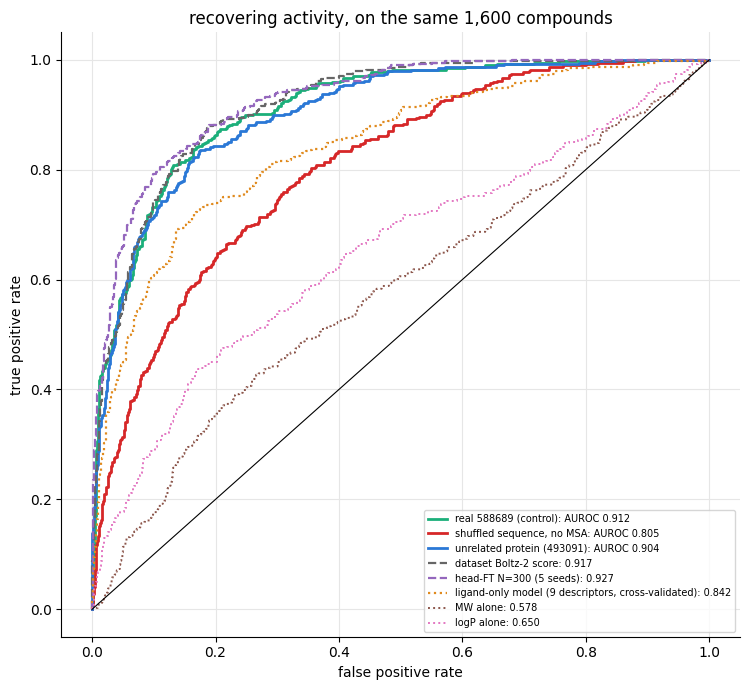

,AUROC,average precision,AP vs chance (x)
score,,,
real 588689 (control),0.912,0.786,3.175
"shuffled sequence, no MSA",0.805,0.588,2.376
unrelated protein (493091),0.904,0.782,3.160
dataset Boltz-2 score,0.917,0.794,3.208
head-FT N=300 (5 seeds),0.927,0.828,3.345
"ligand-only model (9 descriptors, cross-validated)",0.842,0.684,2.765


In [2]:
fig,ax=plt.subplots(figsize=(7.6,7)); rows=[]
for a,lab,c in ARMS:
    if a in W.columns:
        s=W.loc[comp,a].values; f,t,_=roc_curve(y,s); ax.plot(f,t,color=c,lw=2,label=f"{lab}: AUROC {roc_auc_score(y,s):.3f}"); rows.append((lab,roc_auc_score(y,s),average_precision_score(y,s)))
for nm,c,ls in [("dataset Boltz-2 score",NEU,"--"),("head-FT N=300 (5 seeds)",PUR,"--"),("ligand-only model (9 descriptors, cross-validated)",ORG,":")]:
    s=REF[nm].values; f,t,_=roc_curve(y,s); ax.plot(f,t,color=c,ls=ls,lw=1.6,label=f"{nm}: {roc_auc_score(y,s):.3f}"); rows.append((nm,roc_auc_score(y,s),average_precision_score(y,s)))
for col,c in [("MW","#8c564b"),("logP","#e377c2")]:
    s=LP[col].values; au=roc_auc_score(y,s); s=s if au>=0.5 else -s; f,t,_=roc_curve(y,s); ax.plot(f,t,color=c,ls=":",lw=1.4,label=f"{col} alone: {max(au,1-au):.3f}")
ax.plot([0,1],[0,1],color=BLK,lw=0.8); ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate"); ax.legend(fontsize=7,loc="lower right"); ax.set_title("recovering activity, on the same 1,600 compounds")
plt.tight_layout(); plt.show()
T1=pd.DataFrame(rows,columns=["score","AUROC","average precision"]).set_index("score"); T1["AP vs chance (x)"]=T1["average precision"]/y.mean(); display(T1.round(3))

## 2. AUROC and AP with intervals
95% bootstrap intervals over compounds. The dashed line is chance.

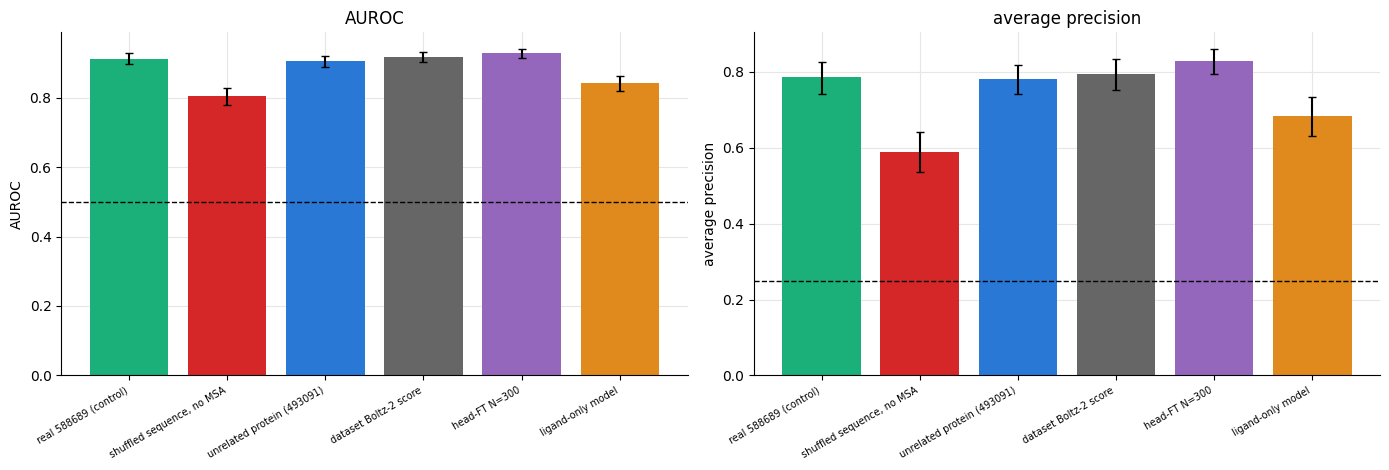

value     lo     hi
metric            score                                          
AUROC             real 588689 (control)       0.912  0.896  0.928
                  shuffled sequence, no MSA   0.805  0.778  0.827
                  unrelated protein (493091)  0.904  0.887  0.921
                  dataset Boltz-2 score       0.917  0.902  0.932
                  head-FT N=300               0.927  0.914  0.941
                  ligand-only model           0.842  0.818  0.864
average precision real 588689 (control)       0.786  0.742  0.826
                  shuffled sequence, no MSA   0.588  0.535  0.642
                  unrelated protein (493091)  0.782  0.742  0.818
                  dataset Boltz-2 score       0.794  0.753  0.832
                  head-FT N=300               0.828  0.794  0.861
                  ligand-only model           0.684  0.632  0.733

In [3]:
rng=np.random.default_rng(0); B=1000; idx=[rng.integers(0,len(y),len(y)) for _ in range(B)]
def boot(s,fn): return np.array([fn(y[i],s[i]) if 0<y[i].sum()<len(i) else np.nan for i in idx])
items=[(lab,W.loc[comp,a].values,c) for a,lab,c in ARMS if a in W.columns]+[("dataset Boltz-2 score",REF["dataset Boltz-2 score"].values,NEU),("head-FT N=300",REF["head-FT N=300 (5 seeds)"].values,PUR),("ligand-only model",REF["ligand-only model (9 descriptors, cross-validated)"].values,ORG)]
fig,axes=plt.subplots(1,2,figsize=(14,4.8)); out=[]
for ax,(nm,fn,chance) in zip(axes,[("AUROC",roc_auc_score,0.5),("average precision",average_precision_score,y.mean())]):
    for i,(lab,s,c) in enumerate(items):
        bs=boot(s,fn); pt=fn(y,s); lo,hi=np.nanpercentile(bs,[2.5,97.5]); ax.bar(i,pt,color=c); ax.errorbar(i,pt,yerr=[[pt-lo],[hi-pt]],color=BLK,capsize=3)
        out.append((nm,lab,pt,lo,hi))
    ax.axhline(chance,ls="--",color=BLK,lw=1); ax.set_xticks(range(len(items))); ax.set_xticklabels([l for l,_,_ in items],rotation=30,ha="right",fontsize=7); ax.set_ylabel(nm); ax.set_title(nm)
plt.tight_layout(); plt.show(); display(pd.DataFrame(out,columns=["metric","score","value","lo","hi"]).round(3).set_index(["metric","score"]))

## 3. Does the true protein add anything? Paired differences
AUROC of the real arm minus each decoy arm, bootstrapped over the same compounds. A difference of zero means the protein made no measurable contribution to separating actives from inactives.

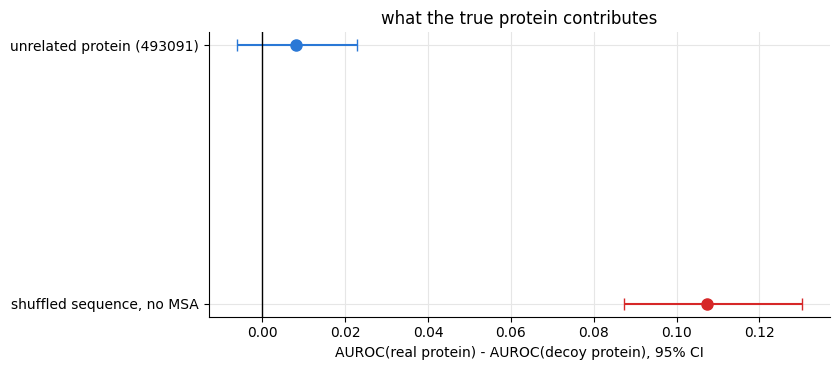

,AUROC gain from the true protein,lo,hi
decoy,,,
"shuffled sequence, no MSA",0.107,0.087,0.130
unrelated protein (493091),0.008,-0.006,0.023


In [4]:
fig,ax=plt.subplots(figsize=(8.5,3.8)); res=[]
for k,(a,lab,c) in enumerate([x for x in ARMS if x[0]!="real" and x[0] in W.columns]):
    sr,sd=W.loc[comp,"real"].values,W.loc[comp,a].values
    d=np.array([roc_auc_score(y[i],sr[i])-roc_auc_score(y[i],sd[i]) for i in idx]); pt=roc_auc_score(y,sr)-roc_auc_score(y,sd); lo,hi=np.percentile(d,[2.5,97.5])
    ax.errorbar(pt,k,xerr=[[pt-lo],[hi-pt]],fmt="o",color=c,capsize=4,ms=8); res.append((lab,pt,lo,hi))
ax.axvline(0,color=BLK,lw=1); ax.set_yticks(range(len(res))); ax.set_yticklabels([r[0] for r in res]); ax.set_xlabel("AUROC(real protein) - AUROC(decoy protein), 95% CI"); ax.set_title("what the true protein contributes")
plt.tight_layout(); plt.show(); display(pd.DataFrame(res,columns=["decoy","AUROC gain from the true protein","lo","hi"]).round(3).set_index("decoy"))

## 4. Do the scores themselves agree across proteins?
Each compound's score against the real protein versus a decoy. If the head reads mostly the ligand, the scores will track each other closely even though the protein is different.

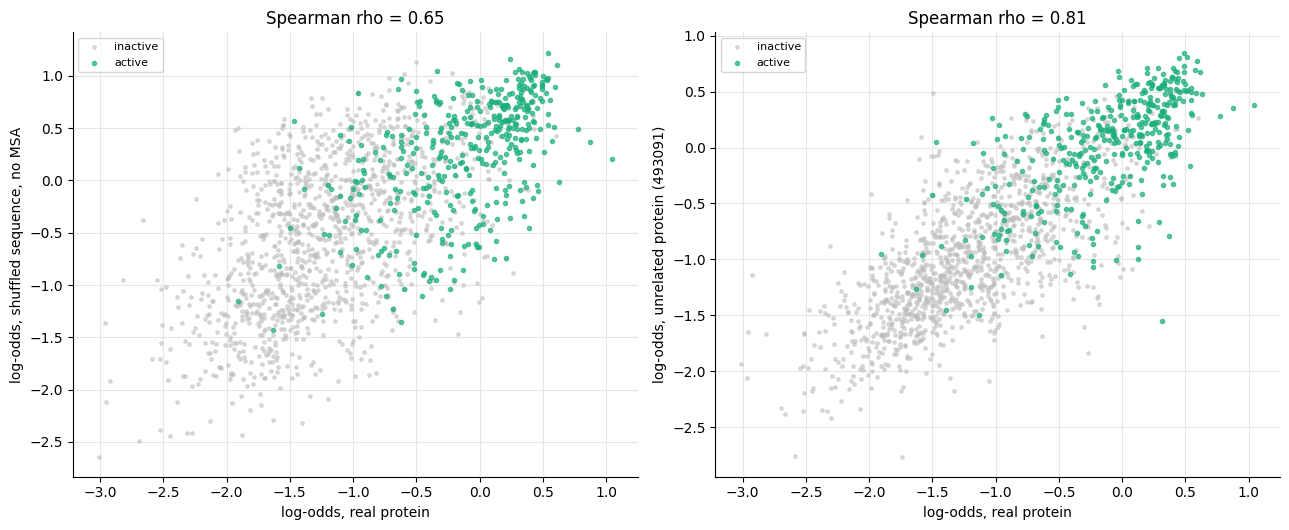

{'shuffled sequence, no MSA': np.float64(0.654), 'unrelated protein (493091)': np.float64(0.809)}


In [5]:
lg=lambda p: np.log(np.clip(p,1e-6,1-1e-6)/(1-np.clip(p,1e-6,1-1e-6)))
dec=[x for x in ARMS if x[0]!="real" and x[0] in W.columns]; fig,axes=plt.subplots(1,max(1,len(dec)),figsize=(6.5*max(1,len(dec)),5.4)); axes=np.atleast_1d(axes); rho={}
for ax,(a,lab,c) in zip(axes,dec):
    x=lg(W.loc[comp,"real"].values); z=lg(W.loc[comp,a].values); r,_=stats.spearmanr(x,z); rho[lab]=r
    ax.scatter(x[y==0],z[y==0],s=6,color="#bdbdbd",alpha=0.5,label="inactive"); ax.scatter(x[y==1],z[y==1],s=9,color=GRN,alpha=0.7,label="active")
    ax.set_xlabel("log-odds, real protein"); ax.set_ylabel(f"log-odds, {lab}"); ax.set_title(f"Spearman rho = {r:.2f}"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show(); print({k:round(v,3) for k,v in rho.items()})

## 5. Where does the score come from? Correlation with the ligand
Spearman correlation of each arm's score with molecular weight and logP, and with the real-protein score.

,Spearman with MW,with logP,with heavy atoms
score,,,
real 588689 (control),-0.003,0.200,-0.020
"shuffled sequence, no MSA",0.012,0.204,0.030
unrelated protein (493091),0.046,0.287,0.025
dataset Boltz-2 score,-0.001,0.209,-0.018


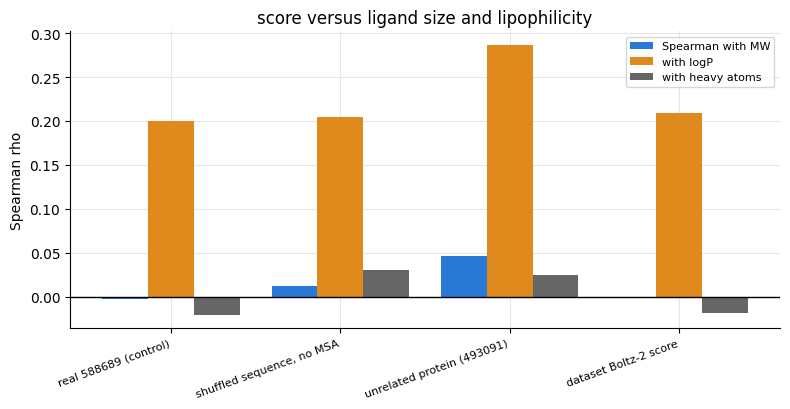

In [6]:
rows=[]
for a,lab,c in ARMS:
    if a in W.columns:
        s=W.loc[comp,a].values; rows.append((lab,stats.spearmanr(s,LP.MW)[0],stats.spearmanr(s,LP.logP)[0],stats.spearmanr(s,LP["heavy atoms"])[0]))
rows.append(("dataset Boltz-2 score",stats.spearmanr(REF["dataset Boltz-2 score"],LP.MW)[0],stats.spearmanr(REF["dataset Boltz-2 score"],LP.logP)[0],stats.spearmanr(REF["dataset Boltz-2 score"],LP["heavy atoms"])[0]))
T5=pd.DataFrame(rows,columns=["score","Spearman with MW","with logP","with heavy atoms"]).set_index("score"); display(T5.round(3))
fig,ax=plt.subplots(figsize=(8,4.2)); x=np.arange(len(T5)); w=0.27
for k,(c,col) in enumerate(zip(T5.columns,[CO,ORG,NEU])): ax.bar(x+(k-1)*w,T5[c],w,label=c,color=col)
ax.axhline(0,color=BLK,lw=1); ax.set_xticks(x); ax.set_xticklabels(T5.index,rotation=20,ha="right",fontsize=8); ax.set_ylabel("Spearman rho"); ax.legend(fontsize=8); ax.set_title("score versus ligand size and lipophilicity")
plt.tight_layout(); plt.show()

## 6. Control: does the standard protocol reproduce the dataset's own scores?
The real-protein arm here was rerun from scratch. Its agreement with the dataset's `score_boltz2` and with our No-FT pipeline score shows how much of any difference comes from run-to-run variation rather than the protein.

,Spearman rho
comparison,
real arm vs dataset Boltz-2 score,0.958
real arm vs No-FT (our pipeline),0.959
"real arm vs shuffled sequence, no MSA",0.654
real arm vs unrelated protein (493091),0.809


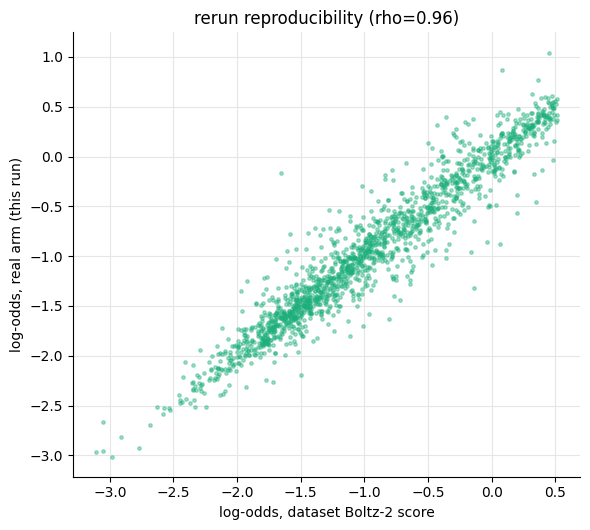

In [7]:
rows=[]
for nm in ["dataset Boltz-2 score","No-FT (our pipeline)"]:
    r,_=stats.spearmanr(W.loc[comp,"real"].values,REF[nm].values); rows.append((f"real arm vs {nm}",r))
for a,lab,c in ARMS[1:]:
    if a in W.columns: rows.append((f"real arm vs {lab}",stats.spearmanr(W.loc[comp,"real"].values,W.loc[comp,a].values)[0]))
display(pd.DataFrame(rows,columns=["comparison","Spearman rho"]).set_index("comparison").round(3))
fig,ax=plt.subplots(figsize=(6,5.4)); x=lg(REF["dataset Boltz-2 score"].values); z=lg(W.loc[comp,"real"].values); ax.scatter(x,z,s=6,alpha=0.4,color=GRN); ax.set_xlabel("log-odds, dataset Boltz-2 score"); ax.set_ylabel("log-odds, real arm (this run)"); ax.set_title(f"rerun reproducibility (rho={stats.spearmanr(x,z)[0]:.2f})")
plt.tight_layout(); plt.show()